In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("usability_all_data.csv")

# Small helper
def classify_answer(ans):
    if not isinstance(ans, str) or ans.strip()=="" or str(ans).lower().startswith("nan"):
        return "no_response"
    s = ans.strip().lower()
    if s.startswith("yes"):
        return "yes"
    if s.startswith("no") or s.startswith("not"):
        return "no"
    return "other"



In [15]:

rating_q = "How would you rate the systems based on this experience?"
rating_df = df[df["question_text"] == rating_q].copy()

def parse_rating_to_10(text):
    """Turn answers like '8 out of 10', '4/5', '4.5' into a 0–10 rating."""
    if not isinstance(text, str):
        return np.nan
    s = text.strip().lower()
    if not s or s == "nan":
        return np.nan

    # pattern: "8 out of 10"
    m = re.search(r"(\d+(?:\.\d+)?)\s*out of\s*(\d+)", s)
    if m:
        val = float(m.group(1))
        denom = float(m.group(2))
        return val * 10.0 / denom if denom != 0 else np.nan

    # pattern: "4/5"
    m = re.search(r"(\d+(?:\.\d+)?)/(\d+)", s)
    if m:
        val = float(m.group(1))
        denom = float(m.group(2))
        return val * 10.0 / denom if denom != 0 else np.nan

    # if <= 5 assume it's out of 5, else out of 10
    m = re.search(r"(\d+(?:\.\d+)?)", s)
    if m:
        val = float(m.group(1))
        if val <= 5:
            return val * 2.0
        else:
            return val

    return np.nan

rating_df["rating_10_auto"] = rating_df["answer_text"].apply(parse_rating_to_10)

print("Auto-parsed ratings (NaN = no explicit number in the answer):")
print(rating_df[["participant_id", "answer_text", "rating_10_auto"]], "\n")

Auto-parsed ratings (NaN = no explicit number in the answer):
    participant_id                                        answer_text  \
5               P1  5\nGrocery (Not preferred -> There’s so many o...   
24              P2  It would be convenient to have this feature (s...   
42              P3  8 out of 10, having categories are great but c...   
60              P4  8 out of 10,  grocery ordering vs food bank or...   
79              P5  Pretty straightforward, what make users use ou...   
98              P6                                        Pretty good   
117             P7                                               4,.5   
136             P8                                               4/5.   
155             P9                                                NaN   
174            P10  4.5 --- 0.5 for minor one, the interface is to...   

     rating_10_auto  
5              10.0  
24              NaN  
42              8.0  
60              8.0  
79              NaN  
98

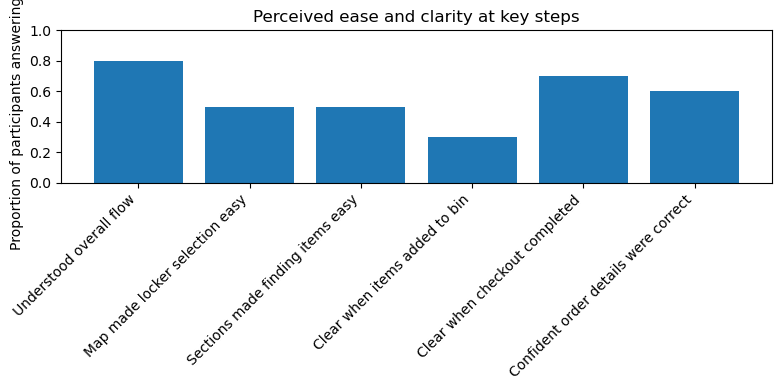

Understood overall flow: 80.0% explicit 'Yes' (out of 10)
Map made locker selection easy: 50.0% explicit 'Yes' (out of 10)
Sections made finding items easy: 50.0% explicit 'Yes' (out of 10)
Clear when items added to bin: 30.0% explicit 'Yes' (out of 10)
Clear when checkout completed: 70.0% explicit 'Yes' (out of 10)
Confident order details were correct: 60.0% explicit 'Yes' (out of 10)


In [17]:
#define all the key wrods
key_questions = {}
for q in df["question_text"].unique():
    if q.startswith("When you opened and used the app for the fi"):
        key_questions["Understood overall flow"] = q
    if q.startswith("Did the map make it easy for you to select a locker location"):
        key_questions["Map made locker selection easy"] = q
    if q.startswith("Did the sections in the app make it easy for you to find and select"):
        key_questions["Sections made finding items easy"] = q
    if q.startswith("Was it clear to you when your selections were successfully added to the checkout bin"):
        key_questions["Clear when items added to bin"] = q
    if q.startswith("Was it clear when you had successfully compl"):
        key_questions["Clear when checkout completed"] = q
    if q.startswith("After completing the checkout, did you feel confident"):
        key_questions["Confident order details were correct"] = q

labels = []
yes_props = []

for label, qtext in key_questions.items():
    subset = df[df["question_text"] == qtext]
    cats = subset["answer_text"].apply(classify_answer)
    yes_count = (cats == "yes").sum()
    total = len(subset)   # should be 10 participants each
    labels.append(label)
    yes_props.append(yes_count / total if total > 0 else np.nan)

plt.figure(figsize=(8, 4))
x = np.arange(len(labels))
plt.bar(x, yes_props)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Proportion of participants answering 'Yes'")
plt.title("Perceived ease and clarity at key steps")
plt.tight_layout()
plt.show()

for label, prop in zip(labels, yes_props):
    print(f"{label}: {prop*100:.1f}% explicit 'Yes' (out of 10)")



Friction feature counts (participants mentioning each area):
Map / locker / location: 2 / 10 participants
Time / scheduling: 0 / 10 participants
Verification / food bank survey: 5 / 10 participants
Item quantity / add-to-cart: 5 / 10 participants
Sections / categories / labels: 3 / 10 participants
Confirmation / QR: 1 / 10 participants


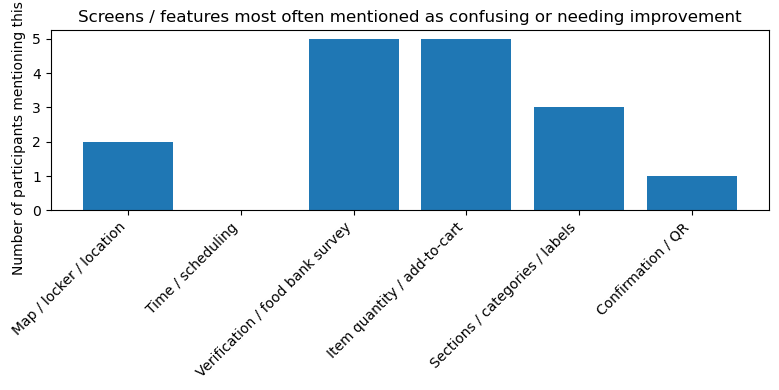

In [18]:
friction_q_texts = [
    "Were there any difficulties using the app, such as selecting items, scheduling pick-up, or navigating the map, at any point?",
    "Is there any part that makes you confused or that you just dislike about it?",
    "Is there any part that makes you confused or that you just dislike about it?\xa0Any Suggestions?",
    "Anything else that stood out to you? Any suggestions?",
]

friction_df = df[df["question_text"].isin(friction_q_texts)].copy()

# Combine all relevant answers 
per_participant = (
    friction_df.groupby("participant_id")["answer_text"]
    .apply(lambda xs: " ".join([str(x) for x in xs if isinstance(x, str)]))
    .reset_index()
)

# Define keywords
feature_keywords = {
    "Map / locker / location": ["map", "locker", "location", "pin"],
    "Time / scheduling": ["time", "schedule", "scheduling", "pickup time", "pick-up time"],
    "Verification / food bank survey": ["survey", "food bank", "verify", "verification"],
    "Item quantity / add-to-cart": ["add to cart", "cart", "bin", "quantity", "quantitty", "+", " - "],
    "Sections / categories / labels": ["category", "categories", "section", "sections", "label", "placeholder", "icons", "wordy"],
    "Confirmation / QR": ["confirm", "confirmation", "qr"],
}

feature_counts = {feature: 0 for feature in feature_keywords.keys()}

for _, row in per_participant.iterrows():
    text = str(row["answer_text"]).lower()
    for feature, keywords in feature_keywords.items():
        if any(kw in text for kw in keywords):
            feature_counts[feature] += 1

print("\nFriction feature counts (participants mentioning each area):")
for feat, c in feature_counts.items():
    print(f"{feat}: {c} / {len(per_participant)} participants")

# Bar plot of friction counts
feat_labels = list(feature_counts.keys())
feat_values = [feature_counts[k] for k in feat_labels]

plt.figure(figsize=(8, 4))
x = np.arange(len(feat_labels))
plt.bar(x, feat_values)
plt.xticks(x, feat_labels, rotation=45, ha="right")
plt.ylabel("Number of participants mentioning this area")
plt.title("Screens / features most often mentioned as confusing or needing improvement")
plt.tight_layout()
plt.show()
